## Libraries and Imports

In [4]:
# Lets Import  (TeamRed: We are importing everything we need at the top)

# Data handling
import pandas as pd 
import numpy as np

# File and system handling
import os
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine learning: preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine learning: regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Machine learning: clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

# Machine learning: anomaly detection
from sklearn.ensemble import IsolationForest

# Machine learning: evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import silhouette_score

# Model saving
import joblib


##### Set File Paths

In [5]:
# Set File Paths  (TeamRed: This is to help us avoid writing long file names everywhere)

DATA_DIR = Path("../data")

household_file = DATA_DIR / "peoplesun_hh_anon.csv"
appliance_file = DATA_DIR / "peoplesun_hhapps_anon.csv"
codebook_file = DATA_DIR / "peoplesun_hh_odk_codebook.xlsx"
choices_file = DATA_DIR / "peoplesun_hh_odk_choices.xlsx"
stoves_file = DATA_DIR / "peoplesun_hhstoves_anon.csv"
weather_file = DATA_DIR / "electricity_consumption_based_weather_dataset.csv"

##### Load Main Datasets

In [7]:
# Load the household and appliance datasets

hh_df = pd.read_csv(household_file, low_memory=False)
apps_df = pd.read_csv(appliance_file)

codebook_df = pd.read_excel(codebook_file)
choices_df = pd.read_excel(choices_file)

print("Datasets loaded successfully!")

Datasets loaded successfully!


##### Load Optional Supporting Datasets

In [8]:
stoves_df = pd.read_csv(stoves_file)
weather_df = pd.read_csv(weather_file)

print("Optional datasets loaded successfully!")

Optional datasets loaded successfully!


##### Inspect Dataset Shapes

In [9]:
# Check Dataset Shapes

print("Household dataset shape:", hh_df.shape)
print("Appliance dataset shape:", apps_df.shape)
print("Codebook shape:", codebook_df.shape)
print("Choices shape:", choices_df.shape)
print("Stoves dataset shape:", stoves_df.shape)
print("Weather dataset shape:", weather_df.shape)

Household dataset shape: (3599, 293)
Appliance dataset shape: (21594, 5)
Codebook shape: (121, 4)
Choices shape: (373, 3)
Stoves dataset shape: (21594, 5)
Weather dataset shape: (1433, 6)


In [10]:
# View household data
display(hh_df.head())

# View appliance data
display(apps_df.head())

# View codebook
display(codebook_df.head())

# View choices file
display(choices_df.head())

,zone,state,eaid,lga,urca_cat,hhid,q102,q103,q104,q105,...,q503__96,q503__98,q503_1,q604_1,q604_2,q604_3,q604_4,q604_5,q604_6,natweight
0,North Central,Niger,NI_197,mashegu,<1hr to small city/town+,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,1,NaN,1,1,...,0,0,NaN,4,2,3,2,3,3,0.039141
1,North Central,Niger,NI_197,mashegu,<1hr to small city/town+,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,1,NaN,1,1,...,0,0,NaN,4,2,3,1,3,3,0.039141
2,North West,Kano,KN_104,garun_malam,<1hr to large city,435c8e27-517a-46b9-af04-48830e086d7a,1,NaN,1,1,...,0,0,NaN,4,3,4,2,4,1,0.109779
3,North West,Kano,KN_104,garun_malam,<1hr to large city,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,1,NaN,1,1,...,0,0,NaN,4,3,4,3,4,2,0.109779
4,North West,Kano,KN_104,garun_malam,<1hr to large city,c62cc5a5-29c5-423b-9543-a7b05bda454b,1,NaN,1,1,...,0,0,NaN,4,2,4,2,4,2,0.109779


,hhid,q403,q403_1,q403_2,q403_3
0,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Fan,4,3,6
1,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Laptop / Computer,2,2,2
2,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Light bulb,8,2,6
3,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Mobile phone charger,3,2,6
4,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Radio,0,0,0


,type_kobo,type,name,label
0,select_one state,select_one,states,State
1,select_one lga,select_one,lgas,Local Government Areas
2,select_one yesnolist,logical,q102,102. Would you like to participate in the survey?
3,select_one rejectlist,select_one,q103,103. Record the reason from the following and ...
4,select_one rellist,select_one,q104,104. What is your relationship to the househol...


,list,name,label
0,yesnolist,1,Yes
1,yesnolist,0,No
2,optionlist,a,A
3,optionlist,b,B
4,rejectlist,1,No adult household member present


In [11]:
# Household column names
print("Household columns:", hh_df.columns.tolist())

# Appliance column names
print("\nAppliance columns:", apps_df.columns.tolist())

Household columns: ['zone', 'state', 'eaid', 'lga', 'urca_cat', 'hhid', 'q102', 'q103', 'q104', 'q105', 'q106', 'q107', 'q108', 'q109', 'q110', 'q201', 'q202', 'q203_1', 'q203_2', 'q203_3', 'q203_4', 'q204', 'q205', 'q206', 'q207_1', 'q207_2', 'q207_3', 'q208', 'q209', 'q210', 'q210_1', 'q211', 'q211__1', 'q211__2', 'q211__3', 'q211__4', 'q211__5', 'q211__6', 'q211__7', 'q211__8', 'q211__9', 'q211__10', 'q211__11', 'q211__12', 'q211__0', 'q211__96', 'q211_1', 'q212', 'q212_1', 'q213', 'q213_1', 'q213_1__1', 'q213_1__2', 'q213_1__96', 'q214', 'q214__1', 'q214__2', 'q214__3', 'q214__4', 'q214__5', 'q214__6', 'q214__7', 'q214__8', 'q214__9', 'q214__10', 'q214__11', 'q214__12', 'q214__13', 'q214__96', 'q215', 'q215_1', 'q215_2', 'q216', 'q216__1', 'q216__2', 'q216__3', 'q216__4', 'q216__5', 'q216__6', 'q216__7', 'q216__8', 'q216__9', 'q216__10', 'q216__11', 'q216__12', 'q216__13', 'q217', 'q217__1', 'q217__2', 'q217__3', 'q217__4', 'q217__5', 'q217__6', 'q217__7', 'q217__8', 'q217__9', 'q2

In [12]:
# Check missing values in household data
print("Top 20 household columns by missing values:")
print(hh_df.isnull().sum().sort_values(ascending=False).head(20))

# Check missing values in appliance data
print("\nMissing values in appliance data:")
print(apps_df.isnull().sum())

Top 20 household columns by missing values:


q103          3599
q304_6        3591
q304_5        3591
q304_7        3591
q405_1__12    3553
q405_1__13    3553
q405_1__96    3553
q405_2        3553
q405_1__11    3553
q405_1__10    3553
q405_1__8     3553
q405_1__7     3553
q405_1__3     3553
q405_1__4     3553
q405_1__5     3553
q405_1__6     3553
q405_1        3553
q405_1__1     3553
q405_1__2     3553
q405_1__9     3553
dtype: int64

Missing values in appliance data:
hhid      0
q403      0
q403_1    0
q403_2    0
q403_3    0
dtype: int64


In [13]:
# Number of unique households in household dataset
print("Unique households in household dataset:", hh_df['hhid'].nunique())

# Number of unique households in appliance dataset
print("Unique households in appliance dataset:", apps_df['hhid'].nunique())

Unique households in household dataset: 3599
Unique households in appliance dataset: 3599


In [14]:
# Check the appliances recorded in the appliance dataset
apps_df['q403'].value_counts()

q403
Fan                     3599
Laptop / Computer       3599
Light bulb              3599
Mobile phone charger    3599
Radio                   3599
Television              3599
Name: count, dtype: int64

In [15]:
# TeamRed: This shows us that we can create useful appliance-based features from the dataset

 Data Visualization - Habiba 

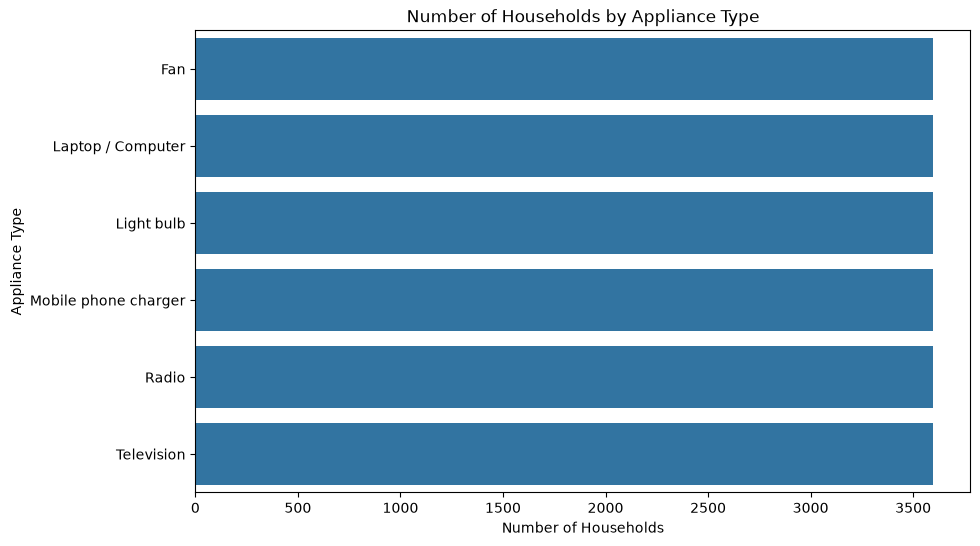

In [16]:
# Visualize the number of households recorded for each appliance

plt.figure(figsize=(10, 6))

sns.countplot(
        data=apps_df,
            y='q403',
                order=apps_df['q403'].value_counts().index
)

plt.title('Number of Households by Appliance Type')
plt.xlabel('Number of Households')
plt.ylabel('Appliance Type')

plt.show()


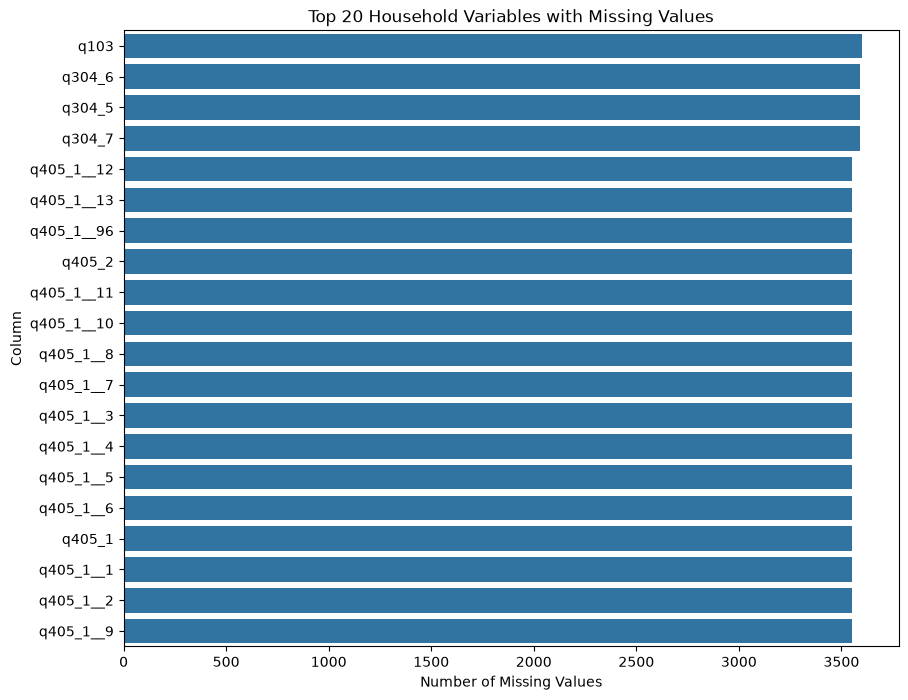

In [17]:
# Visualize the top 20 household columns with missing values

missing_values = (
        hh_df.isnull()
            .sum()
                .sort_values(ascending=False)
                    .head(20)
)

plt.figure(figsize=(10, 8))

sns.barplot(
        x=missing_values.values,
            y=missing_values.index
)

plt.title('Top 20 Household Variables with Missing Values')
plt.xlabel('Number of Missing Values')
plt.ylabel('Column')

plt.show()


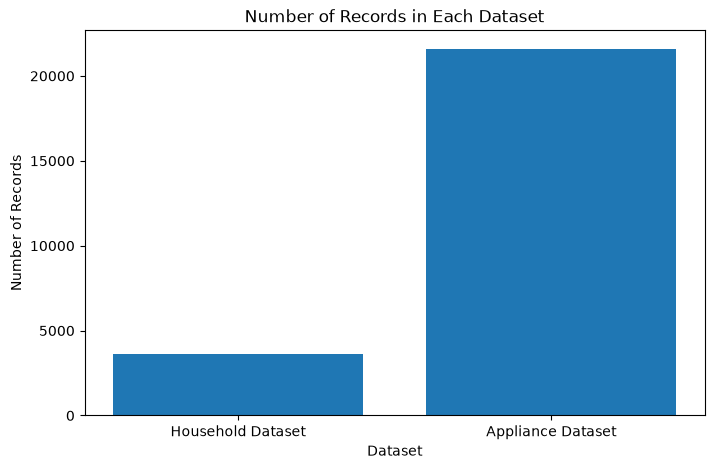

In [18]:
# Compare the number of records in the household and appliance datasets

dataset_sizes = {
        'Household Dataset': len(hh_df),
            'Appliance Dataset': len(apps_df)
}

plt.figure(figsize=(8, 5))

plt.bar(dataset_sizes.keys(), dataset_sizes.values())

plt.title('Number of Records in Each Dataset')
plt.xlabel('Dataset')
plt.ylabel('Number of Records')

plt.show()


 Observations

The appliance dataset contains six appliance categories, with each category appearing 3,599 times. This indicates that the six appliance records are consistently represented across the 3,599 households. 

The missing-value visualization highlights the household variables with the highest number of missing observations, which is useful for guiding future data cleaning an1d preprocessing.
 

The dataset size comparison compares the number the household and appliance datasets. The appliance dataset contains more records because each household has multiple appliance records associated with it. 

DATA VISUALIZATION - EBUBE

Distribution of Household Size
q102
1    3599
Name: count, dtype: int64


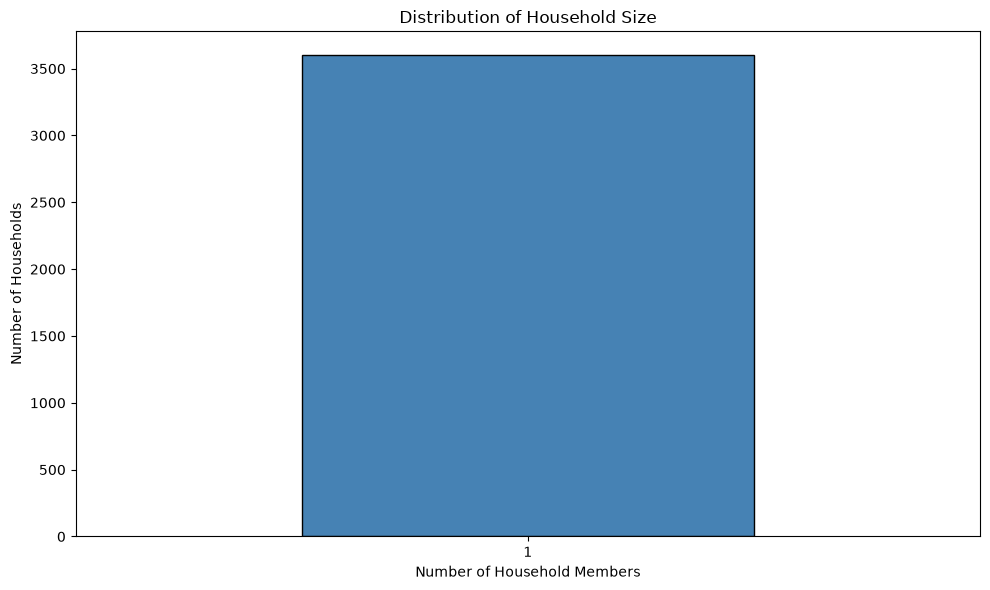

In [19]:

# Display the distribution of household size
household_size = hh_df['q102'].value_counts().sort_index()

# Print the values
print("Distribution of Household Size")
print(household_size)

# Create the bar chart
plt.figure(figsize=(10, 6))

household_size.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

# Add chart title and labels
plt.title("Distribution of Household Size")
plt.xlabel("Number of Household Members")
plt.ylabel("Number of Households")

# Rotate x-axis labels for readability
plt.xticks(rotation=0)

# Improve layout
plt.tight_layout()

# Display the visualization
plt.show()

## Mapping out Important Columns from the Codebook

In [20]:
# Check Important Column Meanings

important_columns = [
    'hhid',
    'zone',
    'state',
    'lga',
    'urca_cat',
    'q201',
    'q203_1',
    'q203_2',
    'q203_3',
    'q203_4',
    'q205',
    'q304_1',
    'q305_1',
    'q305_3',
    'q305_6',
    'q306_3',
    'q306_10',
    'q307_3',
    'q307_10',
    'q402',
    'q403',
    'q404'
]

codebook_df[codebook_df['name'].isin(important_columns)][['name', 'label']]

,name,label
11,q201,201. How many adults live in this household pe...
13,q203_1,203.1. How many household members are less tha...
14,q203_2,203.2. How many household members are between ...
15,q203_3,203.3. How many household members are between ...
16,q203_4,203.4. How many household members are over 55 ...
18,q205,205. How many separate rooms are in all buildi...
54,q304_1,"304.1. On a typical day, how many hours could ..."
64,q305_1,"305.1. On a typical day, how many hours could ..."
66,q305_3,305.3. How many electric generators do you reg...
69,q305_6,305.6. What are the typical monthly costs for ...


In [21]:
# Select Useful Household Columns

selected_household_columns = [
    'hhid',
    'zone',
    'state',
    'lga',
    'urca_cat',

    # Household size and rooms
    'q201',
    'q203_1',
    'q203_2',
    'q203_3',
    'q203_4',
    'q205',

    # Electricity supply hours
    'q304_1',
    'q305_1',
    'q305_3',
    'q305_6',
    'q306_3',
    'q306_10',
    'q307_3',
    'q307_10',

    # Other appliance ownership
    'q404__1',
    'q404__2',
    'q404__3',
    'q404__4',
    'q404__7',
    'q404__11'
]

# Keep only columns that actually exist in the dataset
selected_household_columns = [
    col for col in selected_household_columns if col in hh_df.columns
]

hh_selected = hh_df[selected_household_columns].copy()

hh_selected.head()

,hhid,zone,state,lga,urca_cat,q201,q203_1,q203_2,q203_3,q203_4,...,q306_3,q306_10,q307_3,q307_10,q404__1,q404__2,q404__3,q404__4,q404__7,q404__11
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,North Central,Niger,mashegu,<1hr to small city/town+,5,13,4,1,0,...,NaN,NaN,4.0,3000.0,0,1,0,0,0,1
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,North Central,Niger,mashegu,<1hr to small city/town+,6,4,3,2,1,...,NaN,NaN,6.0,3000.0,0,0,0,0,0,0
2,435c8e27-517a-46b9-af04-48830e086d7a,North West,Kano,garun_malam,<1hr to large city,3,3,2,1,0,...,NaN,NaN,12.0,2000.0,0,0,0,0,0,1
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,North West,Kano,garun_malam,<1hr to large city,3,7,2,1,0,...,NaN,NaN,12.0,2000.0,1,1,0,0,0,1
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,North West,Kano,garun_malam,<1hr to large city,2,4,1,1,0,...,NaN,NaN,5.0,1000.0,0,0,0,0,0,1


In [22]:
# Rename Household Columns TeamRed: The original dataset uses codes like q205 and q307_3. For our project, we need readable names.

rename_map = {
    'q201': 'adult_count',
    'q203_1': 'members_under_18',
    'q203_2': 'members_18_30',
    'q203_3': 'members_31_55',
    'q203_4': 'members_over_55',
    'q205': 'number_of_rooms',

    'q304_1': 'solar_supply_hours',
    'q305_1': 'generator_supply_hours',
    'q305_3': 'generator_count',
    'q305_6': 'generator_monthly_cost',
    'q306_3': 'minigrid_supply_hours',
    'q306_10': 'minigrid_monthly_bill',
    'q307_3': 'national_grid_supply_hours',
    'q307_10': 'national_grid_monthly_bill',

    'q404__1': 'air_cooler_count',
    'q404__2': 'fridge_count',
    'q404__3': 'washing_machine_count',
    'q404__4': 'ac_count',
    'q404__7': 'electric_cooker_count',
    'q404__11': 'thermal_appliance_count'
}

hh_selected = hh_selected.rename(columns=rename_map)

hh_selected.head()

,hhid,zone,state,lga,urca_cat,adult_count,members_under_18,members_18_30,members_31_55,members_over_55,...,minigrid_supply_hours,minigrid_monthly_bill,national_grid_supply_hours,national_grid_monthly_bill,air_cooler_count,fridge_count,washing_machine_count,ac_count,electric_cooker_count,thermal_appliance_count
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,North Central,Niger,mashegu,<1hr to small city/town+,5,13,4,1,0,...,NaN,NaN,4.0,3000.0,0,1,0,0,0,1
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,North Central,Niger,mashegu,<1hr to small city/town+,6,4,3,2,1,...,NaN,NaN,6.0,3000.0,0,0,0,0,0,0
2,435c8e27-517a-46b9-af04-48830e086d7a,North West,Kano,garun_malam,<1hr to large city,3,3,2,1,0,...,NaN,NaN,12.0,2000.0,0,0,0,0,0,1
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,North West,Kano,garun_malam,<1hr to large city,3,7,2,1,0,...,NaN,NaN,12.0,2000.0,1,1,0,0,0,1
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,North West,Kano,garun_malam,<1hr to large city,2,4,1,1,0,...,NaN,NaN,5.0,1000.0,0,0,0,0,0,1


In [23]:
# Step 2D: Clean Household Columns

numeric_household_columns = [
    'adult_count',
    'members_under_18',
    'members_18_30',
    'members_31_55',
    'members_over_55',
    'number_of_rooms',

    'solar_supply_hours',
    'generator_supply_hours',
    'generator_count',
    'generator_monthly_cost',
    'minigrid_supply_hours',
    'minigrid_monthly_bill',
    'national_grid_supply_hours',
    'national_grid_monthly_bill',

    'air_cooler_count',
    'fridge_count',
    'washing_machine_count',
    'ac_count',
    'electric_cooker_count',
    'thermal_appliance_count'
]

for col in numeric_household_columns:
    if col in hh_selected.columns:
        hh_selected[col] = pd.to_numeric(hh_selected[col], errors='coerce').fillna(0)

##### Create Household Size

In [24]:
#  Create Household Size

age_group_columns = [
    'members_under_18',
    'members_18_30',
    'members_31_55',
    'members_over_55'
]

hh_selected['household_size'] = hh_selected[age_group_columns].sum(axis=1)

# If household_size is 0, use adult_count as backup
hh_selected.loc[
    hh_selected['household_size'] == 0,
    'household_size'
] = hh_selected['adult_count']

hh_selected[['hhid', 'household_size', 'number_of_rooms']].head()

,hhid,household_size,number_of_rooms
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,18,8
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,10,9
2,435c8e27-517a-46b9-af04-48830e086d7a,6,5
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,10,10
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,6,3


In [25]:
# Create Daily Supply Hours

supply_hour_columns = [
    'solar_supply_hours',
    'generator_supply_hours',
    'minigrid_supply_hours',
    'national_grid_supply_hours'
]

hh_selected['daily_supply_hours'] = hh_selected[supply_hour_columns].max(axis=1)

# Make sure supply hours do not exceed 24
hh_selected['daily_supply_hours'] = hh_selected['daily_supply_hours'].clip(lower=0, upper=24)

hh_selected[['hhid', 'daily_supply_hours'] + supply_hour_columns].head()

,hhid,daily_supply_hours,solar_supply_hours,generator_supply_hours,minigrid_supply_hours,national_grid_supply_hours
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,4.0,0.0,0.0,0.0,4.0
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,6.0,0.0,6.0,0.0,6.0
2,435c8e27-517a-46b9-af04-48830e086d7a,12.0,0.0,0.0,0.0,12.0
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,12.0,0.0,0.0,0.0,12.0
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,5.0,0.0,0.0,0.0,5.0


In [26]:
# Create Estimated Service Band

def assign_service_band(hours):
    if hours >= 20:
        return 'Band A'
    elif hours >= 16:
        return 'Band B'
    elif hours >= 12:
        return 'Band C'
    elif hours >= 8:
        return 'Band D'
    elif hours >= 4:
        return 'Band E'
    else:
        return 'Below Band E / Low Supply'


hh_selected['estimated_service_band'] = hh_selected['daily_supply_hours'].apply(assign_service_band)

hh_selected['estimated_service_band'].value_counts()

estimated_service_band
Band E                       1253
Below Band E / Low Supply     980
Band D                        658
Band C                        386
Band A                        214
Band B                        108
Name: count, dtype: int64

##### Prepare Appliance Dataset

In [27]:
# Prepare Appliance Dataset

apps_work = apps_df.copy()

# Rename columns
apps_work = apps_work.rename(columns={
    'q403': 'appliance_name',
    'q403_1': 'appliance_count',
    'q403_2': 'daytime_usage_hours',
    'q403_3': 'nighttime_usage_hours'
})

# Convert numeric columns
apps_work['appliance_count'] = pd.to_numeric(apps_work['appliance_count'], errors='coerce').fillna(0)
apps_work['daytime_usage_hours'] = pd.to_numeric(apps_work['daytime_usage_hours'], errors='coerce').fillna(0)
apps_work['nighttime_usage_hours'] = pd.to_numeric(apps_work['nighttime_usage_hours'], errors='coerce').fillna(0)

# Create total daily usage hours
apps_work['daily_usage_hours'] = (
    apps_work['daytime_usage_hours'] + apps_work['nighttime_usage_hours']
)

# Cap usage hours at 24
apps_work['daily_usage_hours'] = apps_work['daily_usage_hours'].clip(lower=0, upper=24)

apps_work.head()

,hhid,appliance_name,appliance_count,daytime_usage_hours,nighttime_usage_hours,daily_usage_hours
0,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Fan,4,3,6,9
1,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Laptop / Computer,2,2,2,4
2,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Light bulb,8,2,6,8
3,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Mobile phone charger,3,2,6,8
4,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Radio,0,0,0,0


In [28]:
# Clean Appliance Names

appliance_name_map = {
    'Light bulb': 'light_bulb',
    'Fan': 'fan',
    'Television': 'television',
    'Mobile phone charger': 'mobile_phone_charger',
    'Laptop / Computer': 'laptop_computer',
    'Radio': 'radio'
}

apps_work['appliance_clean'] = apps_work['appliance_name'].map(appliance_name_map)

apps_work[['hhid', 'appliance_name', 'appliance_clean', 'appliance_count', 'daily_usage_hours']].head(10)

,hhid,appliance_name,appliance_clean,appliance_count,daily_usage_hours
0,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Fan,fan,4,9
1,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Laptop / Computer,laptop_computer,2,4
2,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Light bulb,light_bulb,8,8
3,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Mobile phone charger,mobile_phone_charger,3,8
4,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Radio,radio,0,0
5,000a1b48-1223-4e6c-8d67-6a1c73f8b433,Television,television,2,9
6,00147ada-cbd4-4bc9-8b65-b07ec403cf7e,Fan,fan,2,4
7,00147ada-cbd4-4bc9-8b65-b07ec403cf7e,Laptop / Computer,laptop_computer,0,0
8,00147ada-cbd4-4bc9-8b65-b07ec403cf7e,Light bulb,light_bulb,7,5
9,00147ada-cbd4-4bc9-8b65-b07ec403cf7e,Mobile phone charger,mobile_phone_charger,2,3


In [29]:
apps_work['appliance_clean'].value_counts()

appliance_clean
fan                     3599
laptop_computer         3599
light_bulb              3599
mobile_phone_charger    3599
radio                   3599
television              3599
Name: count, dtype: int64

##### Convert Appliance Rows into Household Columns

In [30]:
# Step 2J: Pivot Appliance Count and Usage Hours

# Appliance count table
appliance_count_pivot = apps_work.pivot_table(
    index='hhid',
    columns='appliance_clean',
    values='appliance_count',
    aggfunc='sum',
    fill_value=0
)

appliance_count_pivot.columns = [
    f"{col}_count" for col in appliance_count_pivot.columns
]


# Appliance usage hours table
appliance_hours_pivot = apps_work.pivot_table(
    index='hhid',
    columns='appliance_clean',
    values='daily_usage_hours',
    aggfunc='mean',
    fill_value=0
)

appliance_hours_pivot.columns = [
    f"{col}_usage_hours" for col in appliance_hours_pivot.columns
]


# Combine both tables
appliance_features = pd.concat(
    [appliance_count_pivot, appliance_hours_pivot],
    axis=1
).reset_index()

appliance_features.head()

,hhid,fan_count,laptop_computer_count,light_bulb_count,mobile_phone_charger_count,radio_count,television_count,fan_usage_hours,laptop_computer_usage_hours,light_bulb_usage_hours,mobile_phone_charger_usage_hours,radio_usage_hours,television_usage_hours
0,000a1b48-1223-4e6c-8d67-6a1c73f8b433,4,2,8,3,0,2,9.0,4.0,8.0,8.0,0.0,9.0
1,00147ada-cbd4-4bc9-8b65-b07ec403cf7e,2,0,7,2,0,1,4.0,0.0,5.0,3.0,0.0,4.0
2,00165d72-086b-4490-9d5d-82446d9a652f,2,0,5,2,0,0,10.0,0.0,9.0,1.0,0.0,0.0
3,002552a4-59d7-4244-bc7f-f749e056d442,1,0,5,0,0,0,6.0,0.0,6.0,0.0,0.0,0.0
4,00334d35-5375-4689-b39e-f000ec097d08,3,0,8,4,0,2,18.0,0.0,9.0,4.0,0.0,5.0


In [31]:
# Step 2K: Merge Household and Appliance Data

energy_base_df = hh_selected.merge(
    appliance_features,
    on='hhid',
    how='left'
)

# Fill missing appliance values with 0
appliance_feature_columns = [
    col for col in energy_base_df.columns
    if '_count' in col or '_usage_hours' in col
]

energy_base_df[appliance_feature_columns] = energy_base_df[appliance_feature_columns].fillna(0)

print("Final base dataset shape:", energy_base_df.shape)

energy_base_df.head()

Final base dataset shape: (3599, 40)


,hhid,zone,state,lga,urca_cat,adult_count,members_under_18,members_18_30,members_31_55,members_over_55,...,light_bulb_count,mobile_phone_charger_count,radio_count,television_count,fan_usage_hours,laptop_computer_usage_hours,light_bulb_usage_hours,mobile_phone_charger_usage_hours,radio_usage_hours,television_usage_hours
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,North Central,Niger,mashegu,<1hr to small city/town+,5,13,4,1,0,...,15,4,0,2,4.0,0.0,5.0,4.0,0.0,7.0
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,North Central,Niger,mashegu,<1hr to small city/town+,6,4,3,2,1,...,12,4,1,1,5.0,0.0,6.0,5.0,3.0,5.0
2,435c8e27-517a-46b9-af04-48830e086d7a,North West,Kano,garun_malam,<1hr to large city,3,3,2,1,0,...,6,3,4,1,12.0,0.0,12.0,5.0,2.0,5.0
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,North West,Kano,garun_malam,<1hr to large city,3,7,2,1,0,...,20,4,4,1,12.0,4.0,12.0,5.0,3.0,5.0
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,North West,Kano,garun_malam,<1hr to large city,2,4,1,1,0,...,3,2,0,0,0.0,0.0,5.0,3.0,0.0,0.0


In [32]:
#  Preview Important Columns

important_preview_columns = [
    'hhid',
    'state',
    'zone',
    'household_size',
    'number_of_rooms',
    'daily_supply_hours',
    'estimated_service_band',
    'light_bulb_count',
    'fan_count',
    'television_count',
    'fridge_count',
    'ac_count',
    'light_bulb_usage_hours',
    'fan_usage_hours',
    'television_usage_hours'
]

important_preview_columns = [
    col for col in important_preview_columns
    if col in energy_base_df.columns
]

energy_base_df[important_preview_columns].head(10)

,hhid,state,zone,household_size,number_of_rooms,daily_supply_hours,estimated_service_band,light_bulb_count,fan_count,television_count,fridge_count,ac_count,light_bulb_usage_hours,fan_usage_hours,television_usage_hours
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,Niger,North Central,18,8,4.0,Band E,15,8,2,1,0,5.0,4.0,7.0
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,Niger,North Central,10,9,6.0,Band E,12,1,1,0,0,6.0,5.0,5.0
2,435c8e27-517a-46b9-af04-48830e086d7a,Kano,North West,6,5,12.0,Band C,6,2,1,0,0,12.0,12.0,5.0
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,Kano,North West,10,10,12.0,Band C,20,6,1,1,0,12.0,12.0,5.0
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,Kano,North West,6,3,5.0,Band E,3,0,0,0,0,5.0,0.0,0.0
5,d3cb220c-85a6-4f47-b6f3-16afac111a0c,Kaduna,North West,4,5,4.0,Band E,5,1,1,1,0,2.0,3.0,5.0
6,2778d899-69d6-4943-896f-de0175716609,Kaduna,North West,9,10,6.0,Band E,10,0,0,0,0,6.0,0.0,0.0
7,6acc2fae-6517-4360-a48a-0b73aa89953c,Niger,North Central,21,9,8.0,Band D,8,0,0,0,0,7.0,0.0,0.0
8,2fb2310c-02b8-4c8c-97de-024b05008625,Niger,North Central,14,8,5.0,Band E,10,0,2,0,0,5.0,0.0,2.0
9,80a0c152-d59a-497e-9ae6-ecd97e4ce53f,Niger,North Central,8,5,6.0,Band E,5,0,0,0,0,6.0,0.0,0.0


In [33]:
#  Final Checks

print("Number of rows:", energy_base_df.shape[0])
print("Number of columns:", energy_base_df.shape[1])

print("\nMissing values in important columns:")
print(energy_base_df[important_preview_columns].isnull().sum())

print("\nDuplicate household IDs:")
print(energy_base_df['hhid'].duplicated().sum())

print("\nService band distribution:")
print(energy_base_df['estimated_service_band'].value_counts())

Number of rows: 3599
Number of columns: 40

Missing values in important columns:
hhid                      0
state                     0
zone                      0
household_size            0
number_of_rooms           0
daily_supply_hours        0
estimated_service_band    0
light_bulb_count          0
fan_count                 0
television_count          0
fridge_count              0
ac_count                  0
light_bulb_usage_hours    0
fan_usage_hours           0
television_usage_hours    0
dtype: int64

Duplicate household IDs:
0

Service band distribution:
estimated_service_band
Band E                       1253
Below Band E / Low Supply     980
Band D                        658
Band C                        386
Band A                        214
Band B                        108
Name: count, dtype: int64


##### Save the Base Dataset

In [34]:
# Save Base Dataset

processed_dir = DATA_DIR / "processed"
processed_dir.mkdir(exist_ok=True)

energy_base_df.to_csv(
    processed_dir / "energy_household_base_step2.csv",
    index=False
)

print("Base household energy dataset saved successfully!")

Base household energy dataset saved successfully!


## Create the Estimated Monthly Electricity Consumption Target

In [35]:
# Step 3A: Load Base Dataset

energy_base_df = pd.read_csv(DATA_DIR / "processed" / "energy_household_base_step2.csv")

print("Dataset loaded successfully!")
print("Shape:", energy_base_df.shape)

energy_base_df.head()

Dataset loaded successfully!
Shape: (3599, 40)


,hhid,zone,state,lga,urca_cat,adult_count,members_under_18,members_18_30,members_31_55,members_over_55,...,light_bulb_count,mobile_phone_charger_count,radio_count,television_count,fan_usage_hours,laptop_computer_usage_hours,light_bulb_usage_hours,mobile_phone_charger_usage_hours,radio_usage_hours,television_usage_hours
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,North Central,Niger,mashegu,<1hr to small city/town+,5,13,4,1,0,...,15,4,0,2,4.0,0.0,5.0,4.0,0.0,7.0
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,North Central,Niger,mashegu,<1hr to small city/town+,6,4,3,2,1,...,12,4,1,1,5.0,0.0,6.0,5.0,3.0,5.0
2,435c8e27-517a-46b9-af04-48830e086d7a,North West,Kano,garun_malam,<1hr to large city,3,3,2,1,0,...,6,3,4,1,12.0,0.0,12.0,5.0,2.0,5.0
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,North West,Kano,garun_malam,<1hr to large city,3,7,2,1,0,...,20,4,4,1,12.0,4.0,12.0,5.0,3.0,5.0
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,North West,Kano,garun_malam,<1hr to large city,2,4,1,1,0,...,3,2,0,0,0.0,0.0,5.0,3.0,0.0,0.0


In [36]:
# Define Appliance Wattage Assumptions

appliance_wattage = {
    'light_bulb': 10,             # 10 watts
    'fan': 60,                    # 60 watts
    'television': 100,            # 100 watts
    'mobile_phone_charger': 5,    # 5 watts
    'laptop_computer': 60,        # 60 watts
    'radio': 10,                  # 10 watts

    # Other appliances from household ownership data
    'fridge': 150,                # 150 watts
    'ac': 1000,                   # 1000 watts
    'washing_machine': 500,       # 500 watts
    'electric_cooker': 1500,      # 1500 watts
    'thermal_appliance': 1200,    # kettle / iron / heating appliance
    'air_cooler': 100             # 100 watts
}

In [37]:
# Define Estimated Usage Hours for other appliances

estimated_usage_hours = {
    'fridge': 12,              # fridge cycles on and off through the day
    'ac': 4,                   # average AC usage per day
    'washing_machine': 0.5,    # occasional daily equivalent
    'electric_cooker': 1,      # average cooking time
    'thermal_appliance': 0.5,  # kettle / iron / heating use
    'air_cooler': 4            # average daily use
}

In [38]:
# Create a Helper Function for Monthly kWh

def calculate_monthly_kwh(count, wattage, daily_hours):
    monthly_kwh = (count * wattage * daily_hours * 30) / 1000
    return monthly_kwh

In [39]:
# Calculate kWh for Recorded Appliances with Usage Hours

recorded_appliances = [
    'light_bulb',
    'fan',
    'television',
    'mobile_phone_charger',
    'laptop_computer',
    'radio'
]

for appliance in recorded_appliances:
    count_col = f"{appliance}_count"
    hours_col = f"{appliance}_usage_hours"
    kwh_col = f"{appliance}_monthly_kwh"

    if count_col in energy_base_df.columns and hours_col in energy_base_df.columns:
        energy_base_df[kwh_col] = calculate_monthly_kwh(
            energy_base_df[count_col],
            appliance_wattage[appliance],
            energy_base_df[hours_col]
        )
    else:
        energy_base_df[kwh_col] = 0

In [40]:
#  Calculate kWh for Other Major Appliances

other_appliances = [
    'fridge',
    'ac',
    'washing_machine',
    'electric_cooker',
    'thermal_appliance',
    'air_cooler'
]

for appliance in other_appliances:
    count_col = f"{appliance}_count"
    kwh_col = f"{appliance}_monthly_kwh"

    if count_col in energy_base_df.columns:
        energy_base_df[kwh_col] = calculate_monthly_kwh(
            energy_base_df[count_col],
            appliance_wattage[appliance],
            estimated_usage_hours[appliance]
        )
    else:
        energy_base_df[kwh_col] = 0

In [41]:
#  Create Total Estimated Monthly kWh

kwh_columns = [
    col for col in energy_base_df.columns
    if col.endswith('_monthly_kwh')
]

energy_base_df['estimated_monthly_kwh'] = energy_base_df[kwh_columns].sum(axis=1)

energy_base_df[
    ['hhid', 'estimated_monthly_kwh'] + kwh_columns
].head()

,hhid,estimated_monthly_kwh,light_bulb_monthly_kwh,fan_monthly_kwh,television_monthly_kwh,mobile_phone_charger_monthly_kwh,laptop_computer_monthly_kwh,radio_monthly_kwh,fridge_monthly_kwh,ac_monthly_kwh,washing_machine_monthly_kwh,electric_cooker_monthly_kwh,thermal_appliance_monthly_kwh,air_cooler_monthly_kwh
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,196.50,22.5,57.6,42.0,2.40,0.0,0.0,54.0,0.0,0.0,0.0,18.0,0.0
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,49.50,21.6,9.0,15.0,3.00,0.0,0.9,0.0,0.0,0.0,0.0,0.0,0.0
2,435c8e27-517a-46b9-af04-48830e086d7a,102.45,21.6,43.2,15.0,2.25,0.0,2.4,0.0,0.0,0.0,0.0,18.0,0.0
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,314.40,72.0,129.6,15.0,3.00,7.2,3.6,54.0,0.0,0.0,0.0,18.0,12.0
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,23.40,4.5,0.0,0.0,0.90,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.0


In [42]:
# Adjust Consumption by Supply Hours

# Supply factor: 24 hours is full availability
energy_base_df['supply_factor'] = energy_base_df['daily_supply_hours'] / 24

# Avoid zero consumption for very low supply households by setting minimum factor
energy_base_df['supply_factor'] = energy_base_df['supply_factor'].clip(lower=0.2, upper=1)

# Adjust estimated consumption
energy_base_df['estimated_monthly_kwh_adjusted'] = (
    energy_base_df['estimated_monthly_kwh'] * energy_base_df['supply_factor']
)

In [43]:
# Rename adjusted value as final target
energy_base_df['estimated_monthly_kwh'] = energy_base_df['estimated_monthly_kwh_adjusted']

##### Create Consumption Category

In [44]:
# Step 3I: Create Consumption Category

energy_base_df['consumption_category'] = pd.qcut(
    energy_base_df['estimated_monthly_kwh'],
    q=4,
    labels=[
        'Low Consumption',
        'Moderate Consumption',
        'High Consumption',
        'Very High Consumption'
    ],
    duplicates='drop'
)

energy_base_df['consumption_category'].value_counts()

consumption_category
Low Consumption          901
Very High Consumption    900
Moderate Consumption     899
High Consumption         899
Name: count, dtype: int64

##### Check the Target Variable

In [45]:
# Step 3J: Inspect Target Variable

print("Target Summary:")
print(energy_base_df['estimated_monthly_kwh'].describe())

print("\nConsumption Category Counts:")
print(energy_base_df['consumption_category'].value_counts())

energy_base_df[
    [
        'hhid',
        'household_size',
        'number_of_rooms',
        'daily_supply_hours',
        'estimated_service_band',
        'estimated_monthly_kwh',
        'consumption_category'
    ]
].head(10)

Target Summary:
count    3599.000000
mean       39.859834
std        58.436122
min         0.000000
25%         4.800000
50%        19.162500
75%        49.612500
max       570.600000
Name: estimated_monthly_kwh, dtype: float64

Consumption Category Counts:
consumption_category
Low Consumption          901
Very High Consumption    900
Moderate Consumption     899
High Consumption         899
Name: count, dtype: int64


,hhid,household_size,number_of_rooms,daily_supply_hours,estimated_service_band,estimated_monthly_kwh,consumption_category
0,d8af8ab5-30ab-4d9f-bfe4-81231dbe5dbf,18,8,4.0,Band E,39.30000,High Consumption
1,e8245d5c-8130-4e78-b4b0-1053b7ecbc9b,10,9,6.0,Band E,12.37500,Moderate Consumption
2,435c8e27-517a-46b9-af04-48830e086d7a,6,5,12.0,Band C,51.22500,Very High Consumption
3,9303fa53-9fd2-41a9-9f0d-9567dbe5168e,10,10,12.0,Band C,157.20000,Very High Consumption
4,c62cc5a5-29c5-423b-9543-a7b05bda454b,6,3,5.0,Band E,4.87500,Moderate Consumption
5,d3cb220c-85a6-4f47-b6f3-16afac111a0c,4,5,4.0,Band E,15.60000,Moderate Consumption
6,2778d899-69d6-4943-896f-de0175716609,9,10,6.0,Band E,4.80000,Low Consumption
7,6acc2fae-6517-4360-a48a-0b73aa89953c,21,9,8.0,Band D,6.20000,Moderate Consumption
8,2fb2310c-02b8-4c8c-97de-024b05008625,14,8,5.0,Band E,9.65625,Moderate Consumption
9,80a0c152-d59a-497e-9ae6-ecd97e4ce53f,8,5,6.0,Band E,7.38750,Moderate Consumption


##### Visualize Estimated Monthly Consumption

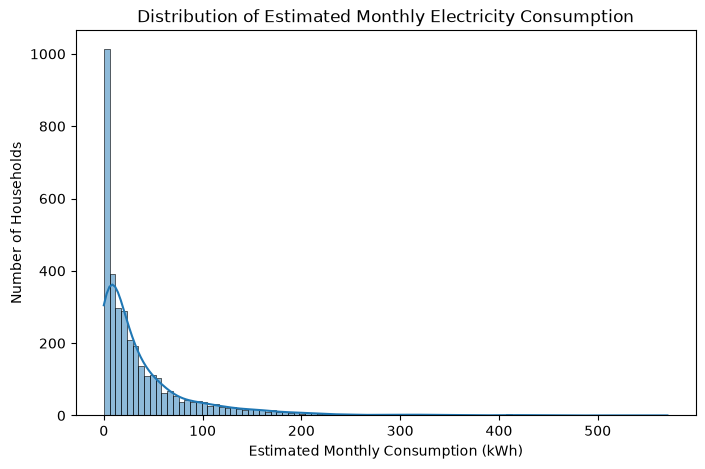

In [46]:
# Visualize Estimated Monthly kWh


plt.figure(figsize=(8, 5))

sns.histplot(
    energy_base_df['estimated_monthly_kwh'],
    kde=True
)

plt.title("Distribution of Estimated Monthly Electricity Consumption")
plt.xlabel("Estimated Monthly Consumption (kWh)")
plt.ylabel("Number of Households")

plt.show()

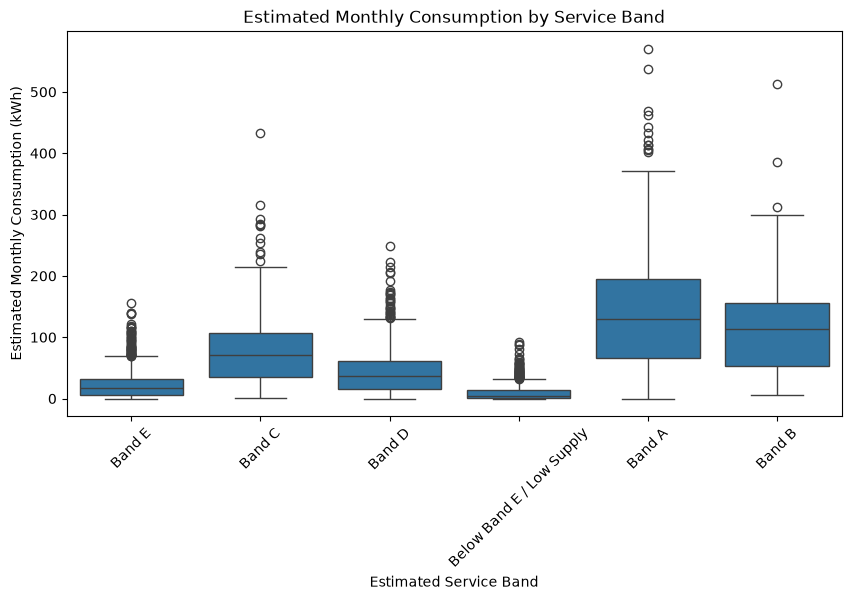

In [47]:
#  Consumption by Estimated Service Band

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=energy_base_df,
    x='estimated_service_band',
    y='estimated_monthly_kwh'
)

plt.title("Estimated Monthly Consumption by Service Band")
plt.xlabel("Estimated Service Band")
plt.ylabel("Estimated Monthly Consumption (kWh)")

plt.xticks(rotation=45)

plt.show()

In [48]:
#  Highest Consumption Households

energy_base_df[
    [
        'hhid',
        'household_size',
        'number_of_rooms',
        'daily_supply_hours',
        'estimated_service_band',
        'light_bulb_count',
        'fan_count',
        'television_count',
        'fridge_count',
        'ac_count',
        'estimated_monthly_kwh',
        'consumption_category'
    ]
].sort_values(by='estimated_monthly_kwh', ascending=False).head(10)

,hhid,household_size,number_of_rooms,daily_supply_hours,estimated_service_band,light_bulb_count,fan_count,television_count,fridge_count,ac_count,estimated_monthly_kwh,consumption_category
3128,89b1b751-e375-463f-9ca4-e519242cc221,6,4,24.0,Band A,7,6,2,1,1,570.60000,Very High Consumption
3417,f4c2cdfa-f97e-4941-9780-e1d0304d855d,12,7,24.0,Band A,18,8,3,1,0,536.70000,Very High Consumption
3003,859c5d97-0e56-4665-a78f-0b9e29c2a990,15,12,18.0,Band B,16,12,12,1,0,512.77500,Very High Consumption
1966,0ae60c53-3ce1-44f9-9a59-051b1c40c988,8,5,24.0,Band A,10,4,2,1,1,468.75000,Very High Consumption
1967,8e91e265-8fd0-420a-a098-700b4ea050d4,6,5,24.0,Band A,10,4,1,1,1,462.60000,Very High Consumption
263,1cc9ff18-f753-4843-85e7-5f941c2e674d,22,8,21.0,Band A,22,8,3,1,0,442.57500,Very High Consumption
1459,df530cc1-3f44-4fab-b2c2-7f4572699cdf,4,9,23.0,Band A,6,3,2,1,1,433.55000,Very High Consumption
3504,0c6565bf-79d2-4314-b1ba-a465cf071924,35,15,12.0,Band C,30,16,10,1,0,432.30000,Very High Consumption
2400,02a645ae-ca9f-4c89-9ac1-1d5151f5f23c,7,6,21.0,Band A,10,5,3,1,1,421.96875,Very High Consumption
3475,1dda71a9-0834-42bd-bfb0-bec9f053c879,6,8,24.0,Band A,13,6,1,1,1,412.95000,Very High Consumption


##### Save the Dataset with Target

In [49]:
# Save Dataset With Target

energy_base_df.to_csv(
    DATA_DIR / "processed" / "energy_household_with_target_step3.csv",
    index=False
)

print("Dataset with estimated monthly kWh target saved successfully!")

Dataset with estimated monthly kWh target saved successfully!


In [50]:
text = "Changes Made by Patrick"
border = "-" * len(text)

print(border)
print(text)
print(border)


-----------------------
Changes Made by Patrick
-----------------------


## Exploratory Data Analysis

#### EDA by Judah Abraham

In [51]:
print("Shape of final dataset:", energy_base_df.shape)
print("\nColumn data types:")
print(energy_base_df.dtypes.value_counts())

energy_base_df.describe(include='number').T

Shape of final dataset: (3599, 56)

Column data types:
float64     30
int64       19
str          6
category     1
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
adult_count,3599.0,3.987497,2.762431,0.0,2.0,3.0000,5.000000,36.0
members_under_18,3599.0,3.050292,3.139073,0.0,1.0,2.0000,4.000000,30.0
members_18_30,3599.0,1.849125,1.737744,0.0,1.0,2.0000,2.000000,24.0
members_31_55,3599.0,1.719644,1.184733,0.0,1.0,2.0000,2.000000,15.0
members_over_55,3599.0,0.418727,0.745932,0.0,0.0,0.0000,1.000000,9.0
number_of_rooms,3599.0,4.784940,3.062783,1.0,3.0,4.0000,6.000000,30.0
solar_supply_hours,3599.0,0.348152,2.304789,0.0,0.0,0.0000,0.000000,24.0
generator_supply_hours,3599.0,1.815226,2.828040,0.0,0.0,0.0000,4.000000,24.0
generator_count,3599.0,0.387608,0.585703,0.0,0.0,0.0000,1.000000,15.0
generator_monthly_cost,3599.0,3600.943318,5970.292324,0.0,0.0,0.0000,6000.000000,95000.0


In [53]:
# Target Variable Summary Statistics

print(energy_base_df['estimated_monthly_kwh'].describe())

skew = energy_base_df['estimated_monthly_kwh'].skew()
print(f"\nSkewness: {skew:.2f}")


count    3599.000000
mean       39.859834
std        58.436122
min         0.000000
25%         4.800000
50%        19.162500
75%        49.612500
max       570.600000
Name: estimated_monthly_kwh, dtype: float64

Skewness: 3.23


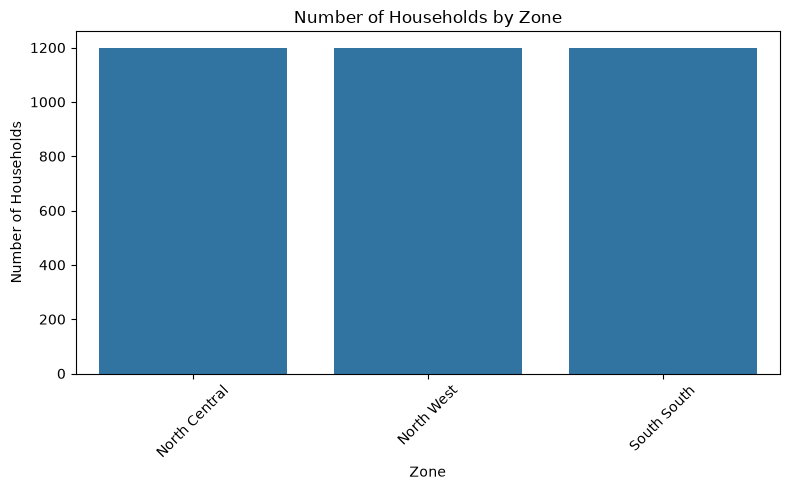

In [55]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=energy_base_df,
    x='zone',
    order=energy_base_df['zone'].value_counts().index
)
plt.title("Number of Households by Zone")
plt.xlabel("Zone")
plt.ylabel("Number of Households")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

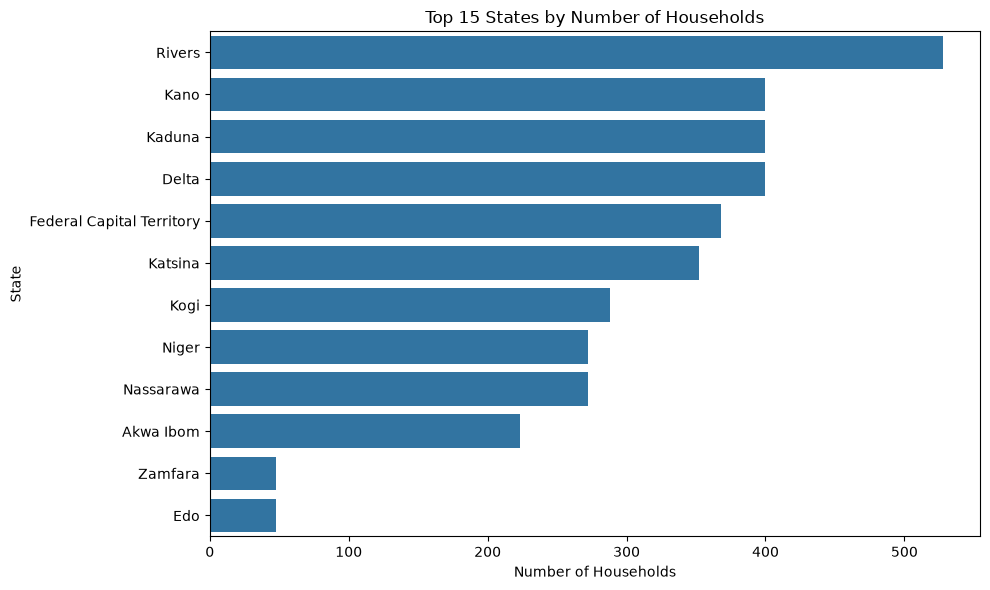

In [56]:
# Households by State (Top 15)

top_states = energy_base_df['state'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Top 15 States by Number of Households")
plt.xlabel("Number of Households")
plt.ylabel("State")
plt.tight_layout()
plt.show()

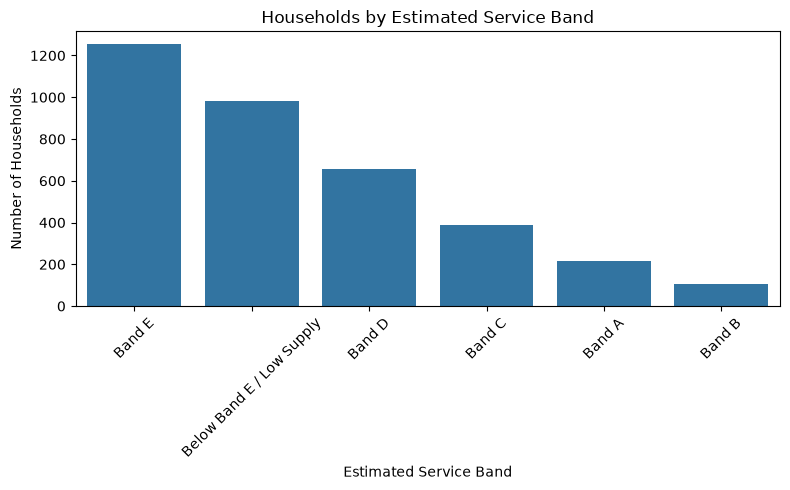

In [57]:
# Households by Estimated Service Band

plt.figure(figsize=(8, 5))
sns.countplot(
    data=energy_base_df,
    x='estimated_service_band',
    order=energy_base_df['estimated_service_band'].value_counts().index
)
plt.title("Households by Estimated Service Band")
plt.xlabel("Estimated Service Band")
plt.ylabel("Number of Households")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
